
#Learning Objectives:


* Formulate  the problem
* Load the Data
* Data Exploration
* Clean The Data
* Discover and Visualize the Data to Gain Insights
* Looking for Correlations
* Prepare the Data for Machine Learning Algorithms
* Save Cleaned Data and Download it



#Student Performance

<h3>About Data </h3>


 <h2>Read Dataset Description</h2>
We want to predict students performance in math in secondary education of two high schools. Please read the description of data set before start.

 [Dataset Description](https://archive.ics.uci.edu/ml/datasets/student+performance)

<h3>Import data</h3>
<p>
here link of raw data set: <a href="https://raw.githubusercontent.com/Ruqyai/Course-DS/master/math-raw.csv"> here</a>.

</p>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [ ]:
import pandas as pd
df = pd.read_csv('math-raw.csv')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18.0,U,GT3,A,4,4,at_home,teacher,...,4,?,4,1,1,3,NaN,5.0,6,6
1,GP,F,17.0,U,GT3,T,1,1,at_home,other,...,5,?,3,1,1,3,NaN,5.0,5,6
2,GP,Female,15.0,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10.0,7.0,8,10
3,GP,F,15.0,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2.0,15.0,14,15
4,GP,F,16.0,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4.0,6.0,10,10


In [ ]:
print(f"Shape: {df.shape}")
df.info()
print(df.isnull().sum())
df.describe()

Shape: (395, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   school      373 non-null    object 
 1   sex         394 non-null    object 
 2   age         394 non-null    float64
 3   address     394 non-null    object 
 4   famsize     395 non-null    object 
 5   Pstatus     395 non-null    object 
 6   Medu        395 non-null    int64  
 7   Fedu        395 non-null    int64  
 8   Mjob        395 non-null    object 
 9   Fjob        395 non-null    object 
 10  reason      395 non-null    object 
 11  guardian    395 non-null    object 
 12  traveltime  395 non-null    int64  
 13  studytime   395 non-null    int64  
 14  failures    393 non-null    float64
 15  schoolsup   395 non-null    object 
 16  famsup      395 non-null    object 
 17  paid        395 non-null    object 
 18  activities  395 non-null    object 
 19  nursery     

,age,Medu,Fedu,traveltime,studytime,failures,famrel,goout,Dalc,Walc,health,absences,G1,G2,G3
count,394.000000,395.000000,395.000000,395.000000,395.000000,393.000000,395.000000,395.000000,395.000000,395.000000,395.000000,393.000000,393.000000,395.000000,395.000000
mean,16.695431,2.749367,2.521519,1.448101,2.035443,0.335878,3.944304,3.108861,1.481013,2.291139,3.554430,5.712468,10.913486,10.713924,10.415190
std,1.277573,1.094735,1.088201,0.697505,0.839240,0.745161,0.896659,1.113278,0.890741,1.287897,1.390303,8.023007,3.327015,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [ ]:
# Fix inconsistent sex column
df['sex'] = df['sex'].replace({'F': 'Female', 'M': 'Male'})
print(df['sex'].value_counts())

# Remove duplicates if any
df = df.drop_duplicates()

sex
Female    207
Male      187
Name: count, dtype: int64


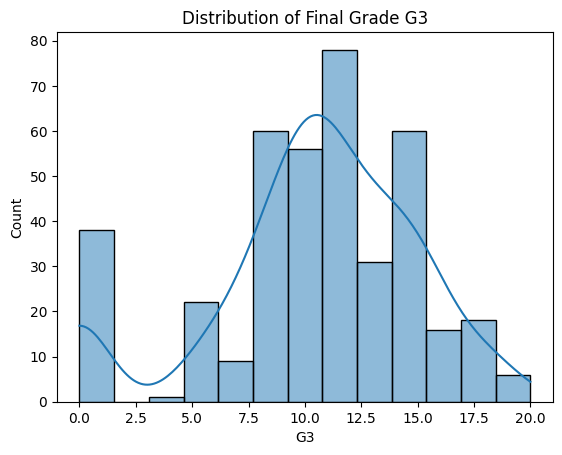

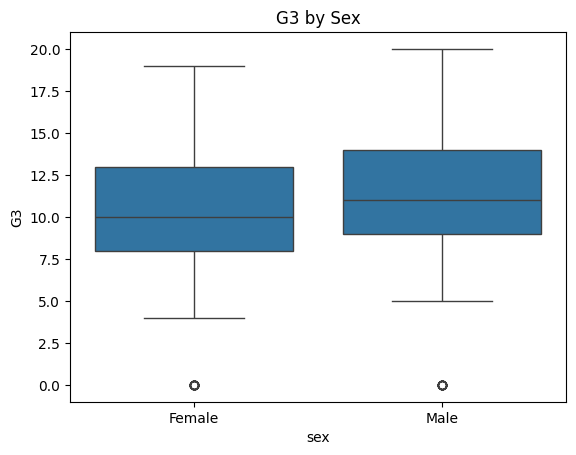

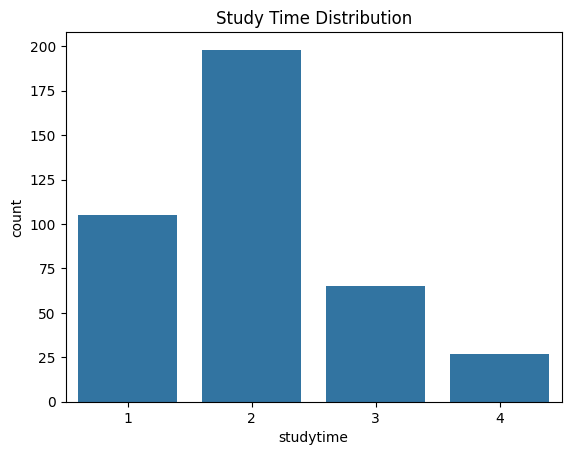

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Distribution of final grades
plt.figure()
sns.histplot(df['G3'], kde=True)
plt.title('Distribution of Final Grade G3')
plt.show()

# 2. Grades by sex
plt.figure()
sns.boxplot(x='sex', y='G3', data=df)
plt.title('G3 by Sex')
plt.show()

# 3. Study time vs final grade
plt.figure()
sns.countplot(x='studytime', data=df)
plt.title('Study Time Distribution')
plt.show()

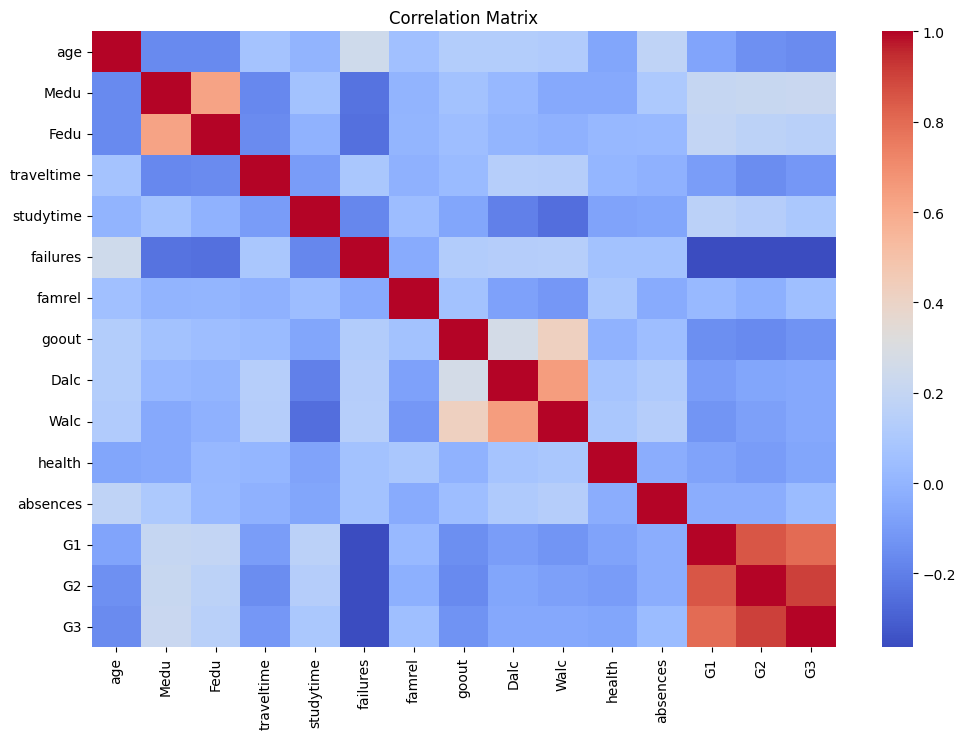

G3            1.000000
G2            0.904868
G1            0.801642
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.033894
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161198
failures     -0.363674
Name: G3, dtype: float64


In [ ]:
# Correlation heatmap for numeric columns
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include=['int64','float64'])
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=False)
plt.title('Correlation Matrix')
plt.show()

print(numeric_df.corr()['G3'].sort_values(ascending=False))

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()

# Encode all object columns
for col in df_ml.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col])

X = df_ml.drop('G3', axis=1)
y = df_ml['G3']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (316, 32)
X_test shape: (79, 32)


In [ ]:
df.to_csv('cleaned_math.csv', index=False)

from google.colab import files
files.download('cleaned_math.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Formulate  the problem

We want to predict the Math Final Grade

So How predict the Math Final Grade?!!

Notice the data is labeled (**Supervised Learning**)

Notice the desired output is number (**Regression**)






###Import libraries




In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Load the Data

###Load the dataset

In [ ]:
file_path = 'https://raw.githubusercontent.com/Ruqyai/Course-DS/master/math-raw.csv'

In [ ]:
#Use the Pandas method read_csv() to load the data from the web address.
df = pd.read_csv(file_path)
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18.0,U,GT3,A,4,4,at_home,teacher,...,4,?,4,1,1,3,NaN,5.0,6,6
1,GP,F,17.0,U,GT3,T,1,1,at_home,other,...,5,?,3,1,1,3,NaN,5.0,5,6
2,GP,Female,15.0,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10.0,7.0,8,10
3,GP,F,15.0,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2.0,15.0,14,15
4,GP,F,16.0,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4.0,6.0,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20.0,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11.0,9.0,9,9
391,MS,M,17.0,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3.0,14.0,16,16
392,MS,M,21.0,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3.0,10.0,8,7
393,MS,M,18.0,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0.0,11.0,12,10


In [ ]:
import numpy as np
df = pd.read_csv(file_path)
df.replace("?", np.nan, inplace = True)
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18.0,U,GT3,A,4,4,at_home,teacher,...,4,NaN,4,1,1,3,NaN,5.0,6,6
1,GP,F,17.0,U,GT3,T,1,1,at_home,other,...,5,NaN,3,1,1,3,NaN,5.0,5,6
2,GP,Female,15.0,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10.0,7.0,8,10
3,GP,F,15.0,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2.0,15.0,14,15
4,GP,F,16.0,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4.0,6.0,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20.0,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11.0,9.0,9,9
391,MS,M,17.0,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3.0,14.0,16,16
392,MS,M,21.0,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3.0,10.0,8,7
393,MS,M,18.0,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0.0,11.0,12,10


In [ ]:

df['sex'] = df['sex'].replace({'F': 'Female', 'M': 'Male', 'f': 'Female', 'm': 'Male'})


for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])


for col in df.select_dtypes(include=['float64','int64']).columns:
    df[col] = df[col].fillna(df[col].median())


print("باقي قيم ناقصة:", df.isnull().sum().sum())
df.head()

باقي قيم ناقصة: 0


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,Female,18.0,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4.0,5.0,6,6
1,GP,Female,17.0,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4.0,5.0,5,6
2,GP,Female,15.0,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10.0,7.0,8,10
3,GP,Female,15.0,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2.0,15.0,14,15
4,GP,Female,16.0,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4.0,6.0,10,10


In [ ]:
print("باقي قيم ناقصة:", df.isnull().sum().sum())

باقي قيم ناقصة: 0


In [ ]:

df_encoded = pd.get_dummies(df, drop_first=True)

print(df_encoded.shape)
df_encoded.head()

(395, 45)


,age,Medu,Fedu,traveltime,studytime,failures,famrel,goout,Dalc,Walc,...,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes,freetime_2,freetime_3,freetime_4,freetime_5
0,18.0,4,4,2,2,0.0,4,4,1,1,...,False,False,True,True,False,False,False,True,False,False
1,17.0,1,1,1,2,0.0,5,3,1,1,...,False,False,False,True,True,False,False,True,False,False
2,15.0,1,1,1,2,3.0,4,2,2,3,...,True,False,True,True,True,False,False,True,False,False
3,15.0,4,2,1,3,0.0,3,2,1,1,...,True,True,True,True,True,True,True,False,False,False
4,16.0,3,3,1,2,0.0,4,2,1,2,...,True,False,True,True,False,False,False,True,False,False


In [ ]:
from sklearn.model_selection import train_test_split
X = df_encoded.drop(columns=['G3'])
y = df_encoded['G3']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 5.859247158706612
R2 Score: 0.7142534185799396


#Clean  the data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   school      395 non-null    object 
 1   sex         395 non-null    object 
 2   age         395 non-null    float64
 3   address     395 non-null    object 
 4   famsize     395 non-null    object 
 5   Pstatus     395 non-null    object 
 6   Medu        395 non-null    int64  
 7   Fedu        395 non-null    int64  
 8   Mjob        395 non-null    object 
 9   Fjob        395 non-null    object 
 10  reason      395 non-null    object 
 11  guardian    395 non-null    object 
 12  traveltime  395 non-null    int64  
 13  studytime   395 non-null    int64  
 14  failures    395 non-null    float64
 15  schoolsup   395 non-null    object 
 16  famsup      395 non-null    object 
 17  paid        395 non-null    object 
 18  activities  395 non-null    object 
 19  nursery     395 non-null    o


##Missing  Values


## Identify and handle missing values

As we can see, several question marks appeared in the dataframe; those are missing values which may hinder our further analysis.
<div>So, how do we identify all those missing values and deal with them?</div>


<h1>How to work with missing data?</h1>

Steps for working with missing data:
<ol>
    <li>identify missing data</li>
    <li>deal with missing data</li>
    <li>correct data format</li>
</ol>

<h1 id="identify_missing_values">1. Identify missing values</h1>

In [ ]:
# TODO : Identify missing values

In [ ]:
# TODO: Check if there is any missing value By heatmap

   
   <h4>Convert "?" to NaN</h4>In the house dataset, missing data comes with the question mark "?".We replace "?" with NaN (Not a Number), which is Python's default missing value marker, for reasons of computational speed and convenience. Here we use the function:  <pre>.replace(A, B, inplace = True) </pre>to replace A by B




In [ ]:
import numpy as np

# replace "?" to NaN
df.replace("?", np.nan, inplace = True)
df.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,Female,18.0,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4.0,5.0,6,6
1,GP,Female,17.0,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4.0,5.0,5,6
2,GP,Female,15.0,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10.0,7.0,8,10
3,GP,Female,15.0,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2.0,15.0,14,15
4,GP,Female,16.0,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4.0,6.0,10,10
5,GP,Male,16.0,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,10.0,15.0,15,15
6,GP,Male,16.0,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0.0,12.0,12,11
7,GP,Female,17.0,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,6.0,6.0,5,6
8,GP,Male,15.0,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0.0,16.0,18,19
9,GP,Male,15.0,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0.0,14.0,15,15


<h1 id="deal_missing_values">2. Deal with missing data</h1>
<b>How to deal with missing data?</b>

<ol>
    <li>drop data<br>
        a. drop the whole row<br>
        b. drop the whole column
    </li>
    <li>replace data (impute)<br>
        a. replace it by mean or median <br>
        b. replace it by frequency<br>
        c. replace it based on inference or other functions
    </li>
</ol>

<h3>Drop the whole row</h3>

In [ ]:
# TODO:Drop the whole row

<h3>Drop the whole column</h3>

In [ ]:
# TODO: Drop the whole column

<h3> Replace it by mean </h3>

In [ ]:
# TODO: Replace it by mean

<h3>Replace by frequency</h3>

In [ ]:
# TODO: Replace by frequency

<h3> Replace by sklearn.impute </h3>

In [ ]:
# TODO: Replace by sklearn.impute

<h1 id="correct_data_format">3. Correct data format</h1>
<b>We are almost there!</b>
<p>The last step in data cleaning is checking and making sure that all data is in the correct format (int, float, text or other).</p>

In Pandas, we use
<p><b>.dtype</b> to check the data type</p>
<p><b>.astype</b> to change the data type</p>

In [ ]:
# TODO: Correct data format

<h3>Remove any duplicates</h3>


In [ ]:
# TODO: Remove any duplicates

<h3>Data Standardization</h3>
<p>
Data is usually collected from different agencies with different formats.
(Data Standardization is also a term for a particular type of data normalization)
</p>
    
<b>What is Standardization?</b>
<p>Standardization is the process of transforming data into a common format which allows the researcher to make the meaningful comparison.
</p>

<h3>Data Normalization </h3>

<b>Why normalization?</b>
<p>Normalization is the process of transforming values of several variables into a similar range. Typical normalizations include scaling the variable so the variable average is 0, scaling the variable so the variance is 1, or scaling variable so the variable values range from 0 to 1
</p>



---

---





# Exploratory Data Analysis (EDA) and Data Visualization


Categorical variables are variables that describe a 'characteristic' of a data unit, and are selected from a small group of categories. The categorical variables can have the type "object" or "int64". A good way to visualize categorical variables is by using boxplots.


<h3>Identify Outliers <h3>

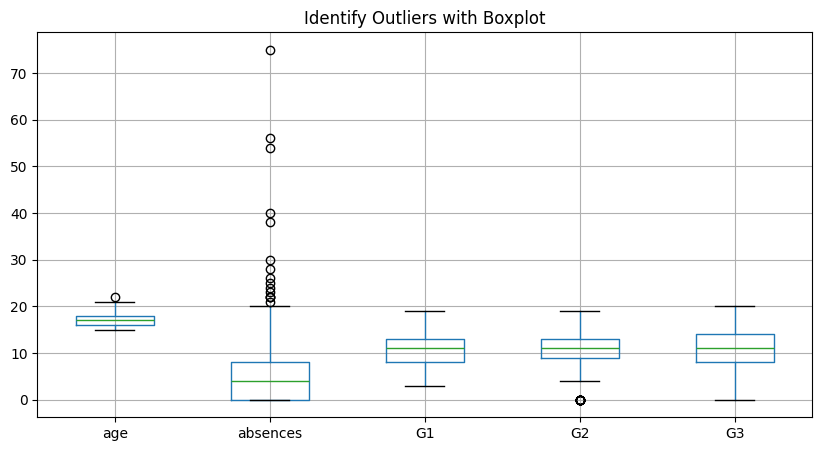

In [ ]:
# TODO: Identify Outliers
import matplotlib.pyplot as plt

numeric_cols = ['age', 'absences', 'G1', 'G2', 'G3']

df[numeric_cols].boxplot(figsize=(10,5))
plt.title("Identify Outliers with Boxplot")
plt.show()

<h3>Remove Outliers</h3>

In [ ]:
# TODO:  Remove Outliers

print(f"قبل: {df.shape[0]}")

df = df[df['absences'] <= 20]

df = df[df['age'] <= 20]

print(f"بعد: {df.shape[0]}")
print(f"حذفنا {395 - df.shape[0]} طلاب شاذين")

قبل: 395
بعد: 378
حذفنا 17 طلاب شاذين


##Discover and Visualize the Data to Gain Insights

<h4>Individual Variables </h4>


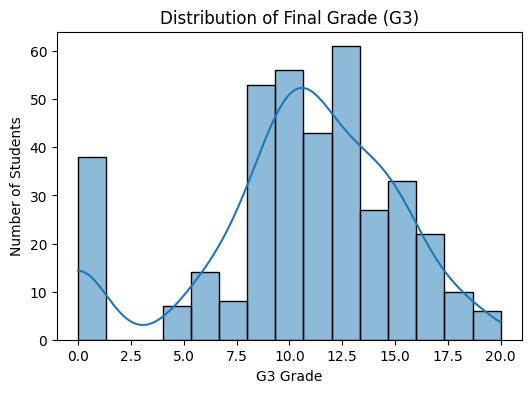

In [ ]:
# TODO: Show Individual Variable as graph
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.histplot(df['G3'], bins=15, kde=True)
plt.title("Distribution of Final Grade (G3)")
plt.xlabel("G3 Grade")
plt.ylabel("Number of Students")
plt.show()

<h4>Relationships Between Variables</h4>

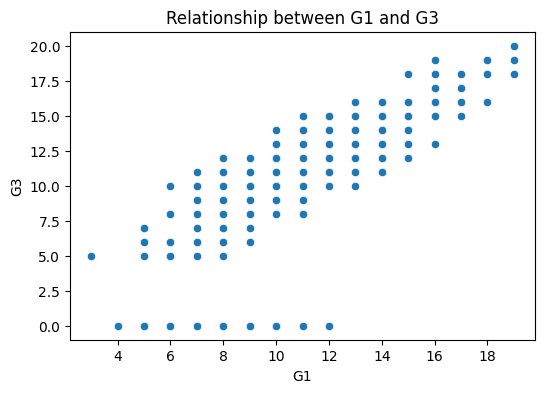

In [ ]:
 # TODO: Show relationship between two Variables
 plt.figure(figsize=(6,4))
sns.scatterplot(x=df['G1'], y=df['G3'])
plt.title("Relationship between G1 and G3")
plt.xlabel("G1")
plt.ylabel("G3")
plt.show()

<h4>Weak and Strong Relationships<h4>

G1           0.798915
G2           0.902692
G3           1.000000
absences     0.088789
age         -0.165300
studytime    0.097958
Name: G3, dtype: float64


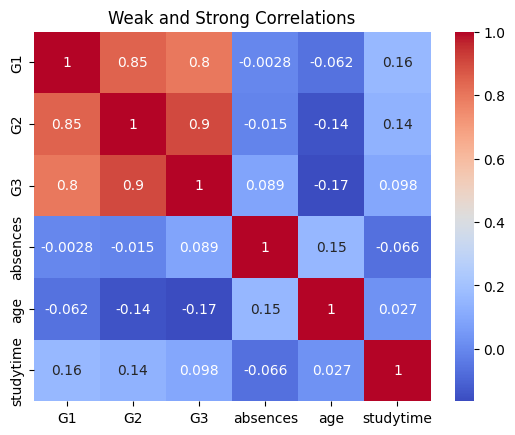

In [ ]:
# TODO: Show some weak and Strong Relationships

corr = df[['G1','G2','G3','absences','age','studytime']].corr()
print(corr['G3'])


import seaborn as sns
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Weak and Strong Correlations")
plt.show()

##Looking for Correlations

<h3>Correlation and Causation</h3>

<b> Correlation: </b> a measure of the extent of interdependence between variables.

<b> Causation: </b>the relationship between cause and effect between two variables.

It is important to know the difference between these two and that correlation does not imply causation. Determining correlation is much simpler the determining causation as causation may require independent experimentation.

G3           1.000000
G2           0.902692
G1           0.798915
studytime    0.097958
absences     0.088789
age         -0.165300
Name: G3, dtype: float64


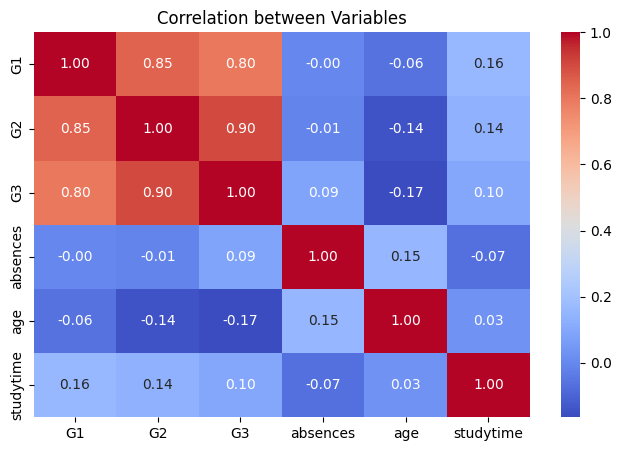

In [ ]:
# OTDO : Show the Correlation between variables
import seaborn as sns
import matplotlib.pyplot as plt


corr = df[['G1','G2','G3','absences','age','studytime']].corr()
print(corr['G3'].sort_values(ascending=False))


plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation between Variables")
plt.show()

#Feature  Engineering

* Construct new features
* Combine two features or uncombine a feature
*	Select features

<h3>Conclusion: Important Variables</h3>
We now have a better idea of what our data looks like and which variables are important to take into account when predicting the house price.

##Select features

In [ ]:
# TODO: Select the important features

df['failures'] = pd.to_numeric(df['failures'], errors='coerce')
df['absences'] = pd.to_numeric(df['absences'], errors='coerce')

df['failures'] = df['failures'].fillna(df['failures'].mean())
df['absences'] = df['absences'].fillna(df['absences'].mean())

df['avg_grade'] = (df['G1'] + df['G2']) / 2

important_features = ['G1', 'G2', 'avg_grade', 'studytime', 'failures', 'absences', 'age']
X = df[important_features]
y = df['G3']

print("Important features selected:")
print(X.head())
print(f"\nShape: {X.shape}")
print(f"Any NaN remaining? {X.isnull().sum().sum()}")

Important features selected:
     G1  G2  avg_grade  studytime  failures  absences   age
0   5.0   6        5.5          2       0.0       4.0  18.0
1   5.0   5        5.0          2       0.0       4.0  17.0
2   7.0   8        7.5          2       3.0      10.0  15.0
3  15.0  14       14.5          3       0.0       2.0  15.0
4   6.0  10        8.0          2       0.0       4.0  16.0

Shape: (378, 7)
Any NaN remaining? 0


<h3>Save Cleaned Data and Download it <h3>

In [ ]:

df.to_csv('cleaned_math_final.csv', index=False)
print("File saved successfully!")
print(f"Final shape: {df.shape}")

File saved successfully!
Final shape: (378, 34)


#Choose and  fit model




In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = LinearRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print("Model trained successfully!")

MSE: 2.80
R2 Score: 0.8524
Model trained successfully!
